In [ ]:
## 2026.06.24 LLY create the pred_statistic_visual_xenium_all.ipynb
##            plot the statistical results of the prediction on all cases

In [ ]:
## for AI edit
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
import os
os.chdir(f'{path}Hist2Pheno/data/')
!pwd

## Load function
import sys
from pathlib import Path
_repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code")
_xenium_dir = _repo / "Xenium_lung"
_pkg_dir = _repo / "Hist2Pheno_pkg"
for _p in (_pkg_dir, _xenium_dir):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

# Unified plotting selector (avoids repeating per-tier scheme strings).
PAN_ORGAN = "xenium_lung"

## load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger("ome_zarr").setLevel(logging.ERROR)


Xenium_lung_dir = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/'

## AUROC on Complete_Cases

In [ ]:
## StarDist external validation — load latest metrics from all Complete_Cases (n=25)
from pathlib import Path

COMPLETE_CASES_ROOT = Path(Xenium_lung_dir) / "Data/Complete_Cases"
MODEL_SUFFIX = "_project_all_UNI"
METRICS_NAME = "validation_external_stardist_matched_metrics.csv"
OUT_DIR = COMPLETE_CASES_ROOT

# CSV keys (insample_{key}_*) map to h5ad obs column names for plotting
# TIER_KEYS = ["l2", "l1", "l1_head", "l12", "l3", "l4"]
# TIER_ORDER = [
#     "final_CT",                 # Level2
#     "final_lineage",            # Level1 (L2 probs aggregated to lineage)
#     "final_lineage (L1 head)",  # Level1 (direct L1 head softmax)
#     "final_sublineage",         # Level12
#     "CNiche",                   # Level3
#     "TNiche",                   # Level4
# ]


TIER_KEYS = ["l2", "l1_head", "l12", "l3", "l4"]
TIER_ORDER = [
    "final_CT",                 # Level2
    "final_lineage",            # Level1 (direct L1 head softmax)
    "final_sublineage",         # Level12
    "CNiche",                   # Level3
    "TNiche",                   # Level4
]


METRIC_ORDER = ["accuracy", "macro_f1", "weighted_f1", "macro_auc"]
METRIC_LABELS = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "macro_auc": "Macro AUROC",
}


def discover_external_metrics(cases_root: Path) -> pd.DataFrame:
    """Load the latest row per sample from each metrics CSV."""
    rows = []
    missing = []
    for sample_dir in sorted(cases_root.iterdir()):
        if not sample_dir.is_dir() or sample_dir.name.startswith(("_", ".")):
            continue
        if sample_dir.name in {"stardist_external_validation_summary"}:
            continue
        if not (sample_dir / f"{sample_dir.name}{MODEL_SUFFIX}").is_dir():
            continue
        csv_path = (
            sample_dir
            / f"{sample_dir.name}{MODEL_SUFFIX}"
            / "result"
            / METRICS_NAME
        )
        if not csv_path.is_file():
            missing.append(sample_dir.name)
            continue
        df = pd.read_csv(csv_path)
        if df.empty:
            missing.append(sample_dir.name)
            continue
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        row = df.sort_values("timestamp").iloc[-1].copy()
        row["sample"] = sample_dir.name
        rows.append(row)

    if missing:
        print(f"WARNING: missing metrics CSV for {len(missing)} sample(s): {missing}")

    out = pd.DataFrame(rows).reset_index(drop=True)
    print(f"Loaded latest metrics for {len(out)} / {len(rows) + len(missing)} Complete_Cases samples")
    return out


metrics_wide = discover_external_metrics(COMPLETE_CASES_ROOT)
metrics_wide = metrics_wide.sort_values("sample").reset_index(drop=True)
display(metrics_wide[["sample", "timestamp", "insample_l2_macro_f1", "insample_l1_macro_f1", "insample_l2_macro_auc"]].head())

# Long format for seaborn boxplots
long_rows = []
for _, row in metrics_wide.iterrows():
    for tier_key, tier_label in zip(TIER_KEYS, TIER_ORDER):
        for metric_key in METRIC_ORDER:
            col = f"insample_{tier_key}_{metric_key}"
            if col not in row.index:
                continue
            val = row[col]
            if pd.isna(val):
                continue
            long_rows.append(
                {
                    "sample": row["sample"],
                    "label": tier_label,
                    "metric": METRIC_LABELS[metric_key],
                    "metric_key": metric_key,
                    "value": float(val),
                }
            )

metrics_long = pd.DataFrame(long_rows)
metrics_long["label"] = pd.Categorical(metrics_long["label"], categories=TIER_ORDER, ordered=True)
metrics_long["metric"] = pd.Categorical(
    metrics_long["metric"],
    categories=[METRIC_LABELS[m] for m in METRIC_ORDER],
    ordered=True,
)
print(f"Long table: {len(metrics_long):,} metric values")

## save the metrics
# metrics_wide.to_csv(OUT_DIR / "validation_external_stardist_matched_all_samples_latest.csv", index=False)
# metrics_long.to_csv(OUT_DIR / "validation_external_stardist_matched_long.csv", index=False)
# print(f"Saved: {OUT_DIR}")


Loaded latest metrics for 25 / 26 Complete_Cases samples


,sample,timestamp,insample_l2_macro_f1,insample_l1_macro_f1,insample_l2_macro_auc
0,THD0008,2026-06-24 14:33:03,0.099771,0.372765,0.652996
1,THD0011,2026-06-24 14:36:03,0.111852,0.366421,0.637981
2,TILD117LA,2026-06-24 14:40:42,0.136802,0.487850,0.753884
3,TILD117MA1,2026-06-24 14:43:46,0.179752,0.592262,0.792887
4,TILD175MA,2026-06-24 14:46:24,0.190819,0.540368,0.791839


Long table: 500 metric values


In [ ]:
## Summary statistics across 25 datasets
summary_rows = []
for tier_key, tier_label in zip(TIER_KEYS, TIER_ORDER):
    for metric_key in METRIC_ORDER:
        col = f"insample_{tier_key}_{metric_key}"
        if col not in metrics_wide.columns:
            continue
        s = metrics_wide[col].dropna()
        if s.empty:
            continue
        summary_rows.append(
            {
                "label": tier_label,
                "metric": METRIC_LABELS[metric_key],
                "n": int(s.shape[0]),
                "mean": s.mean(),
                "std": s.std(ddof=1),
                "median": s.median(),
                "q25": s.quantile(0.25),
                "q75": s.quantile(0.75),
                "min": s.min(),
                "max": s.max(),
            }
        )

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.round(4)
display(summary_df)

## save the summary
# summary_df.to_csv(OUT_DIR / "validation_external_stardist_summary_stats.csv", index=False)
# print(f"Saved summary stats -> {OUT_DIR / 'validation_external_stardist_summary_stats.csv'}")


,label,metric,n,mean,std,median,q25,q75,min,max
0,final_CT,Accuracy,25,0.2074,0.0528,0.2016,0.1689,0.2425,0.1299,0.3331
1,final_CT,Macro F1,25,0.1284,0.0368,0.1176,0.1024,0.1506,0.0781,0.2241
2,final_CT,Weighted F1,25,0.2085,0.0542,0.1995,0.1754,0.2409,0.1348,0.3414
3,final_CT,Macro AUROC,25,0.6989,0.0601,0.6958,0.6530,0.7374,0.6092,0.8444
4,final_lineage,Accuracy,25,0.4843,0.1101,0.4572,0.3990,0.5451,0.3501,0.7222
5,final_lineage,Macro F1,25,0.4318,0.0781,0.4035,0.3712,0.4779,0.3321,0.6241
6,final_lineage,Weighted F1,25,0.4828,0.1087,0.4551,0.3993,0.5404,0.3462,0.7198
7,final_lineage,Macro AUROC,25,0.6958,0.0797,0.6699,0.6377,0.7429,0.5926,0.8710
8,final_sublineage,Accuracy,25,0.4361,0.1009,0.3991,0.3531,0.4974,0.3244,0.6555
9,final_sublineage,Macro F1,25,0.3523,0.0735,0.3439,0.3024,0.3892,0.2404,0.5100


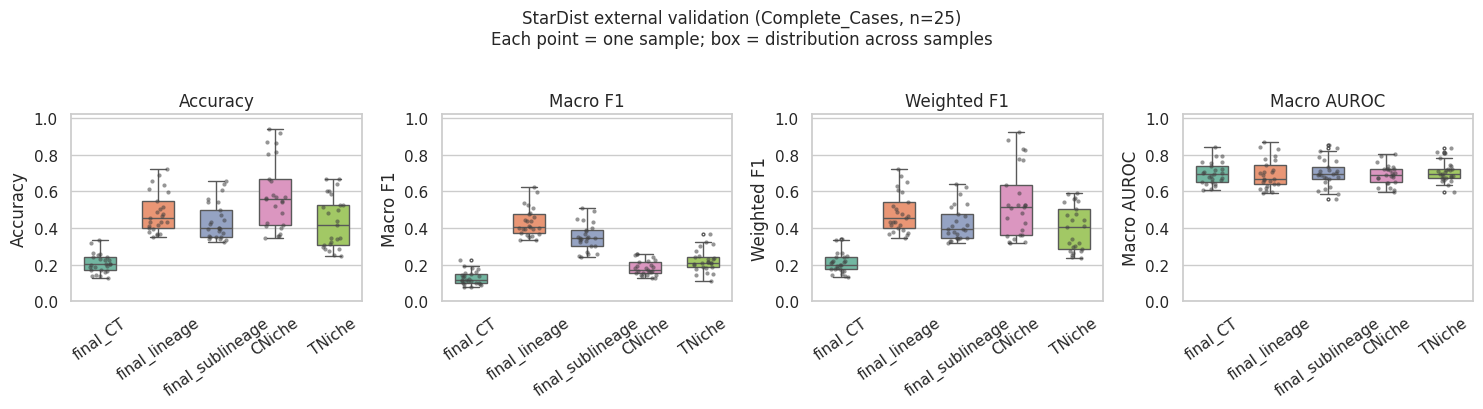

In [ ]:
## Boxplots: Accuracy / Macro F1 / Weighted F1 / Macro AUROC by biological label
sns.set_theme(style="whitegrid", context="notebook")

palette = sns.color_palette("Set2", n_colors=len(TIER_ORDER))

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)
axes = axes.ravel()

for ax, metric_key in zip(axes, METRIC_ORDER):
    sub = metrics_long[metrics_long["metric_key"] == metric_key]
    sns.boxplot(
        data=sub,
        x="label",
        y="value",
        order=TIER_ORDER,
        palette=palette,
        width=0.55,
        fliersize=2,
        ax=ax,
    )
    sns.stripplot(
        data=sub,
        x="label",
        y="value",
        order=TIER_ORDER,
        color="0.25",
        alpha=0.55,
        size=3,
        jitter=0.18,
        ax=ax,
    )
    ax.set_title(METRIC_LABELS[metric_key])
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS[metric_key])
    ax.set_ylim(0, 1.02)
    ax.tick_params(axis="x", rotation=35)

fig.suptitle(
    "StarDist external validation (Complete_Cases, n=25)\n"
    "Each point = one sample; box = distribution across samples",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()

## save the boxplot
# fig_path = OUT_DIR / "boxplot_metrics_by_tier.pdf"
# plt.savefig(fig_path, bbox_inches="tight")
# plt.savefig(fig_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
# print(f"Saved: {fig_path}")

plt.show()

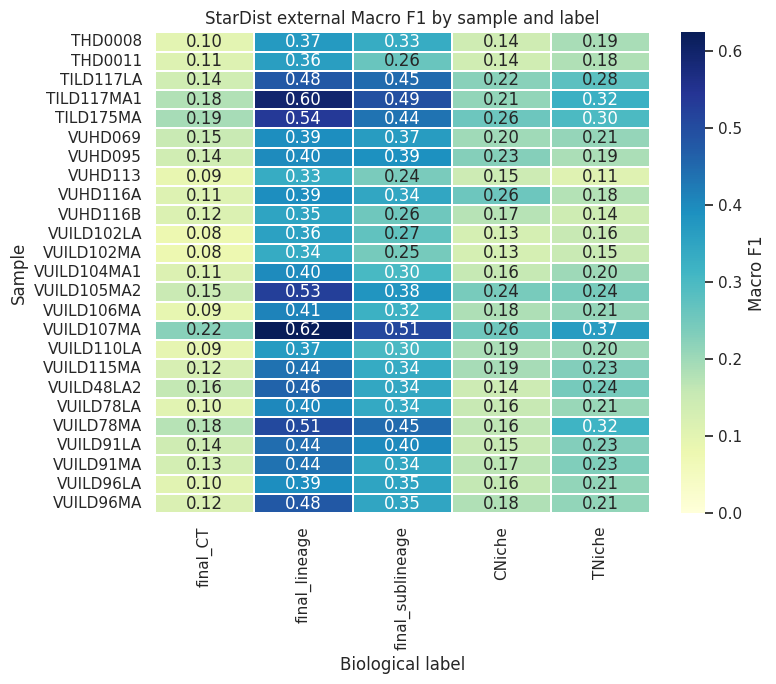

In [ ]:
## Heatmap: per-sample Macro F1 across tiers
f1_cols = [f"insample_{k}_macro_f1" for k in TIER_KEYS if f"insample_{k}_macro_f1" in metrics_wide.columns]
heat = metrics_wide.set_index("sample")[f1_cols].copy()
heat.columns = TIER_ORDER[: len(f1_cols)]

fig, ax = plt.subplots(figsize=(8, max(6, 0.28 * len(heat))))
sns.heatmap(
    heat,
    cmap="YlGnBu",
    vmin=0,
    vmax=max(0.6, float(heat.max().max())),
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "Macro F1"},
    ax=ax,
)
ax.set_title("StarDist external Macro F1 by sample and label")
ax.set_xlabel("Biological label")
ax.set_ylabel("Sample")
plt.tight_layout()

## save the heatmap
# heat_path = OUT_DIR / "heatmap_macro_f1_sample_x_tier.pdf"
# plt.savefig(heat_path, bbox_inches="tight")
# plt.savefig(heat_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
# print(f"Saved: {heat_path}")

plt.show()

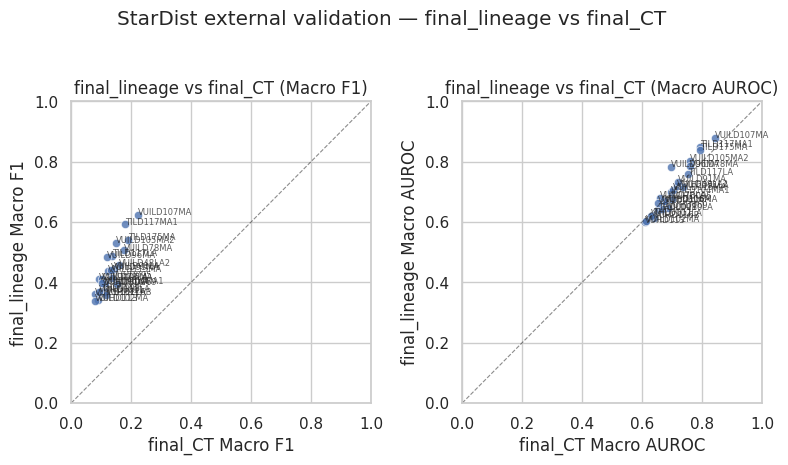

In [ ]:
## final_lineage vs final_CT (Macro F1 and AUROC)
fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))

pairs = [
    ("insample_l2_macro_f1", "insample_l1_macro_f1", "Macro F1"),
    ("insample_l2_macro_auc", "insample_l1_macro_auc", "Macro AUROC"),
]
for ax, (xcol, ycol, label) in zip(axes, pairs):
    sub = metrics_wide.dropna(subset=[xcol, ycol])
    ax.scatter(sub[xcol], sub[ycol], s=35, alpha=0.8, edgecolor="white", linewidth=0.5)
    lims = [0, 1]
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(f"final_CT {label}")
    ax.set_ylabel(f"final_lineage {label}")
    ax.set_title(f"final_lineage vs final_CT ({label})")
    for _, r in sub.iterrows():
        ax.annotate(r["sample"], (r[xcol], r[ycol]), fontsize=6, alpha=0.75)

plt.suptitle(
    "StarDist external validation — final_lineage vs final_CT",
    y=1.03,
)
plt.tight_layout()

## save the scatter
# scatter_path = OUT_DIR / "scatter_final_lineage_vs_final_CT_f1_auc.pdf"
# plt.savefig(scatter_path, bbox_inches="tight")
# plt.savefig(scatter_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
# print(f"Saved: {scatter_path}")

plt.show()


,sample,insample_l2_macro_f1,insample_l2_accuracy,insample_l2_macro_auc,insample_l1_macro_f1,insample_l12_macro_f1,insample_l3_macro_f1,insample_l4_macro_f1
15,VUILD107MA,0.2241,0.3331,0.8444,0.6234,0.5100,0.2555,0.3675
4,TILD175MA,0.1908,0.3198,0.7918,0.5404,0.4350,0.2575,0.2993
3,TILD117MA1,0.1798,0.2571,0.7929,0.5923,0.4929,0.2145,0.3244
20,VUILD78MA,0.1751,0.2614,0.7602,0.5057,0.4480,0.1649,0.3151
18,VUILD48LA2,0.1589,0.2016,0.7153,0.4570,0.3430,0.1443,0.2447
5,VUHD069,0.1535,0.2427,0.6863,0.3930,0.3676,0.1994,0.2097
13,VUILD105MA2,0.1506,0.2425,0.7596,0.5312,0.3822,0.2435,0.2421
21,VUILD91LA,0.1411,0.1717,0.7374,0.4451,0.3999,0.1540,0.2310
2,TILD117LA,0.1368,0.1875,0.7539,0.4878,0.4461,0.2221,0.2770
6,VUHD095,0.1366,0.2511,0.6993,0.4149,0.3892,0.2267,0.1862


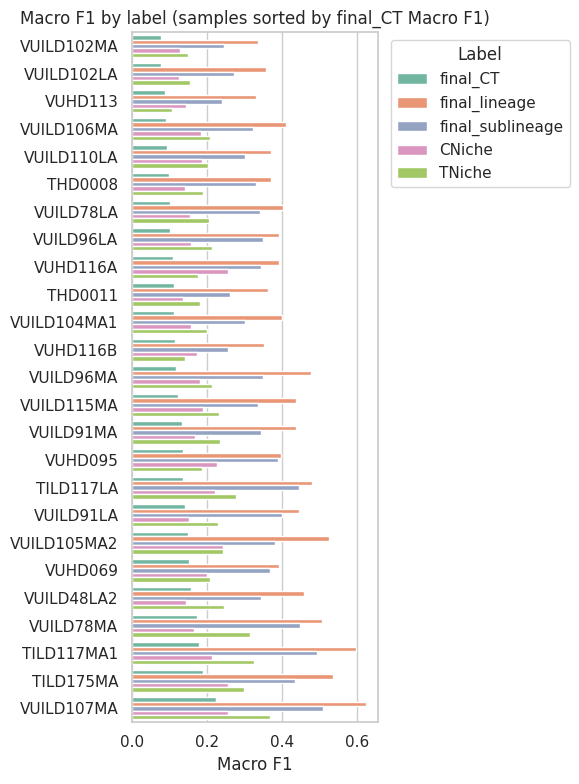

In [ ]:
## Rank samples by final_CT Macro F1
rank_cols = [
    "sample",
    "insample_l2_macro_f1",
    "insample_l2_accuracy",
    "insample_l2_macro_auc",
    "insample_l1_macro_f1",
    "insample_l12_macro_f1",
    "insample_l3_macro_f1",
    "insample_l4_macro_f1",
]
rank_df = metrics_wide[rank_cols].copy().sort_values("insample_l2_macro_f1", ascending=False)
rank_df = rank_df.round(4)
display(rank_df)

rank_df.to_csv(OUT_DIR / "validation_external_stardist_rank_by_l2_macro_f1.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 8))
order = rank_df["sample"].tolist()
plot_df = metrics_long[
    (metrics_long["metric_key"] == "macro_f1") & (metrics_long["sample"].isin(order))
].copy()
plot_df["sample"] = pd.Categorical(plot_df["sample"], categories=order[::-1], ordered=True)
sns.barplot(
    data=plot_df,
    y="sample",
    x="value",
    hue="label",
    hue_order=TIER_ORDER,
    palette=palette,
    ax=ax,
)
ax.set_xlabel("Macro F1")
ax.set_ylabel("")
ax.set_title("Macro F1 by label (samples sorted by final_CT Macro F1)")
ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## save the barplot
# bar_path = OUT_DIR / "barplot_macro_f1_by_sample_tier.pdf"
# plt.savefig(bar_path, bbox_inches="tight")
# plt.savefig(bar_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
# print(f"Saved: {bar_path}")

plt.show()

## Pooled Level2 ROC — all Complete_Cases — Per-sample

Per-sample trained models: read ``validation_external_stardist_matched_AUROC.csv`` from
``Complete_Cases/{sample}/{sample}_project_all_UNI/result/``, align ``final_CT`` to a global class union,
then plot one multiclass ROC on all StarDist-matched cells pooled across samples.


### results

Discovering per-sample AUROC CSVs under /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases ...
  THD0008: 36,781 cells, 45 local classes
  THD0011: 23,573 cells, 40 local classes
  TILD117LA: 10,288 cells, 42 local classes
  TILD117MA1: 9,345 cells, 41 local classes
  TILD175MA: 15,863 cells, 43 local classes
  VUHD069: 15,330 cells, 36 local classes
  VUHD095: 7,401 cells, 35 local classes
  VUHD113: 7,098 cells, 30 local classes
  VUHD116A: 2,920 cells, 34 local classes
  VUHD116B: 8,125 cells, 33 local classes
  VUILD102LA: 24,925 cells, 38 local classes
  VUILD102MA: 30,066 cells, 40 local classes
  VUILD104MA1: 20,754 cells, 42 local classes
  VUILD105MA2: 7,614 cells, 39 local classes
  VUILD106MA: 91,766 cells, 46 local classes
  VUILD107MA: 30,615 cells, 44 local classes
  VUILD110LA: 96,369 cells, 45 local classes
  VUILD115MA: 58,841 cells, 43 local classes
  VUILD48LA2: 3,558 cells, 34 local classes
  V

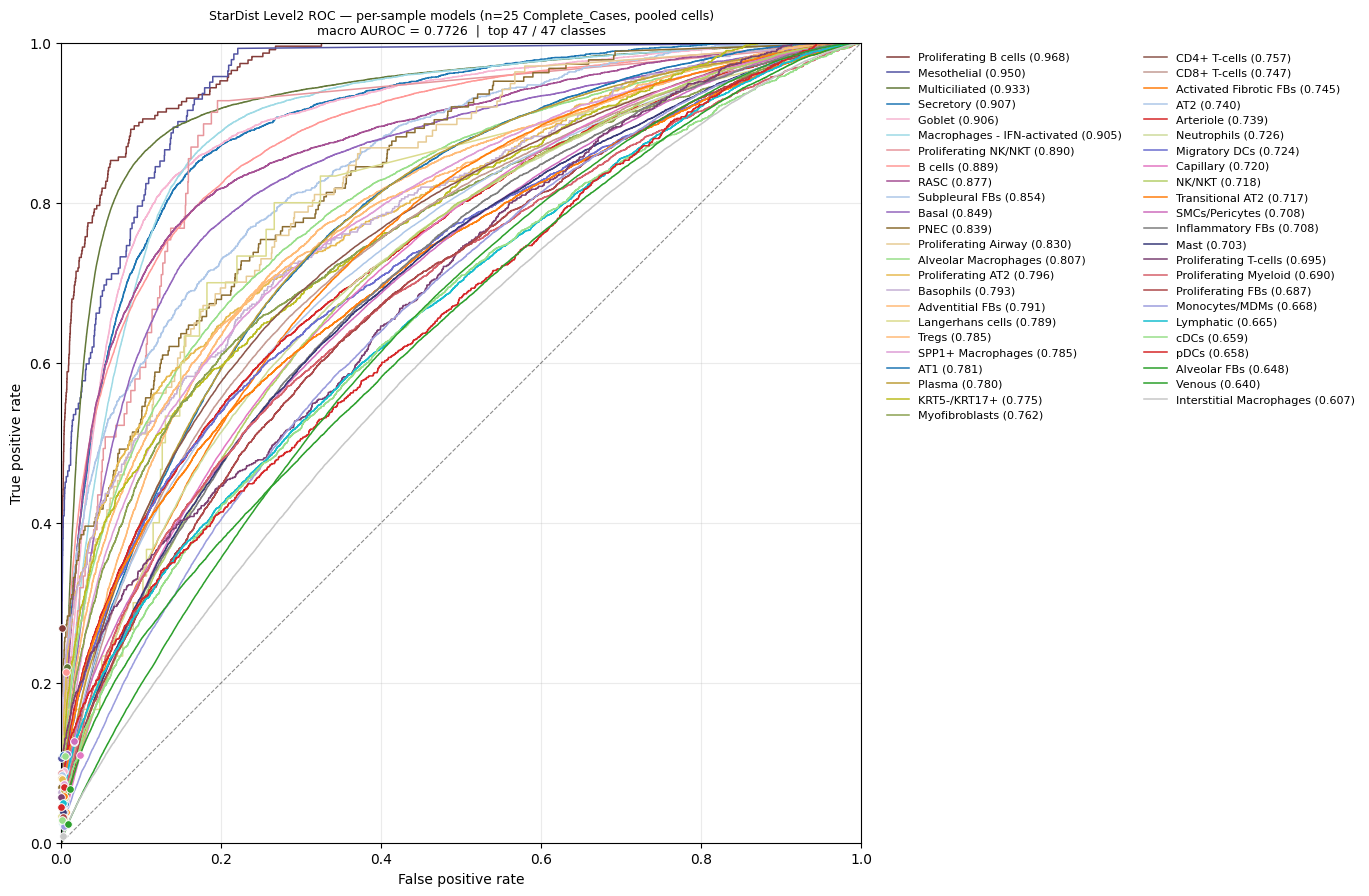

Pooled macro AUROC (per-sample): 0.7726


,class_idx,class_name,auc_ovr,n_pos
32,32,Proliferating B cells,0.968456,231
21,21,Mesothelial,0.950261,142
24,24,Multiciliated,0.933122,26383
40,40,Secretory,0.907442,3304
13,13,Goblet,0.905854,6269
19,19,Macrophages - IFN-activated,0.904987,8724
35,35,Proliferating NK/NKT,0.890493,69
7,7,B cells,0.889135,16605
37,37,RASC,0.876931,5554
41,41,Subpleural FBs,0.853622,1042


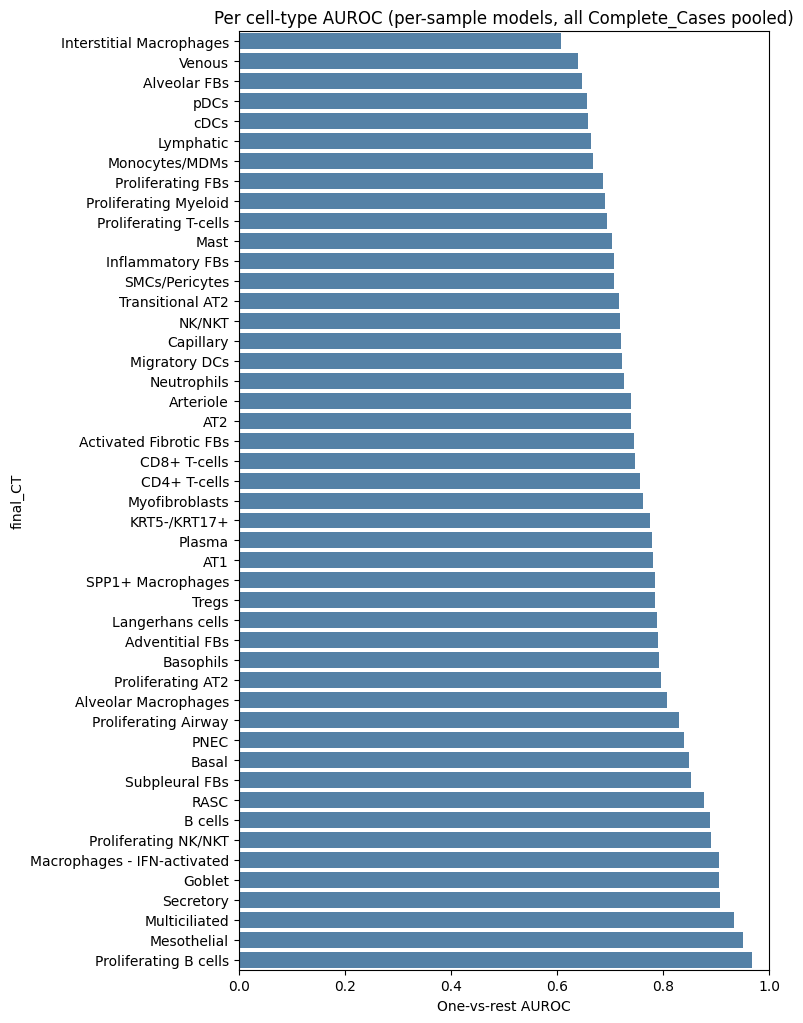

In [ ]:
import sys
from pathlib import Path

_repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import importlib
import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    concat_stardist_auroc_level2_all_samples,
    plot_stardist_level2_roc_pooled,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Per-sample model: AUROC CSV under Complete_Cases/{sample}/{sample}_project_all_UNI/result/
if "Xenium_lung_dir" not in globals():
    _path = "/home/lingyu/ssd2/Python/"
    Xenium_lung_dir = f"{_path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/"

DATA_ROOT = Path(Xenium_lung_dir) / "Data"
COMPLETE_CASES_ROOT = DATA_ROOT / "Complete_Cases"
MODEL_SUFFIX = "_project_all_UNI"
OUT_DIR_PER_SAMPLE = COMPLETE_CASES_ROOT

print(f"Discovering per-sample AUROC CSVs under {COMPLETE_CASES_ROOT} ...")
pooled_per_sample = concat_stardist_auroc_level2_all_samples(
    COMPLETE_CASES_ROOT,
    out_dir=OUT_DIR_PER_SAMPLE,
    model_suffix=MODEL_SUFFIX,
    layout="per_sample",
)
print(
    f"\nPooled (per-sample models): {len(pooled_per_sample['concat_df']):,} cells from "
    f"{len(pooled_per_sample['sample_paths'])} samples; "
    f"{len(pooled_per_sample['global_class_names'])} global final_CT classes"
)
if pooled_per_sample["missing_samples"]:
    print("Missing AUROC CSV:", pooled_per_sample["missing_samples"])

roc_info_per_sample = plot_stardist_level2_roc_pooled(
    pooled_per_sample["y_true"],
    pooled_per_sample["y_score"],
    pooled_per_sample["global_class_names"],
    save_path=str(OUT_DIR_PER_SAMPLE / "roc_stardist_level2_per_sample_all_Complete_Cases_pooled.pdf"),
    title=(
        "StarDist Level2 ROC — per-sample models "
        f"(n={len(pooled_per_sample['sample_paths'])} Complete_Cases, pooled cells)"
    ),
    pan_organ=PAN_ORGAN,
    figsize=(8.0, 8.0),
    max_curves=len(pooled_per_sample["global_class_names"]),
)
plt.show()
if roc_info_per_sample:
    print(f"Pooled macro AUROC (per-sample): {roc_info_per_sample['macro_auc']:.4f}")
    per_class_ps = roc_info_per_sample["per_class_auc"].sort_values("auc_ovr", ascending=False)
    display(per_class_ps.head(15))
    per_class_ps.to_csv(
        OUT_DIR_PER_SAMPLE / "roc_stardist_level2_per_sample_all_Complete_Cases_per_class_auc.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(8, max(5, 0.22 * len(per_class_ps))))
    plot_df = per_class_ps.sort_values("auc_ovr", ascending=True)
    sns.barplot(data=plot_df, y="class_name", x="auc_ovr", ax=ax, color="steelblue")
    ax.set_xlim(0, 1)
    ax.set_xlabel("One-vs-rest AUROC")
    ax.set_ylabel("final_CT")
    ax.set_title("Per cell-type AUROC (per-sample models, all Complete_Cases pooled)")
    plt.tight_layout()
    plt.show()


## Pooled Level2 ROC — all Complete_Cases — Cross-dataset model

StarDist predictions from the **shared cross-dataset model** (trained on all 25 Complete_Cases), under ``Data/result/stardist/{sample}/``.


### result

Discovering AUROC CSVs under /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/result/stardist ...
  THD0008: 36,781 cells, 47 local classes
  THD0011: 23,573 cells, 47 local classes
  TILD117LA: 10,288 cells, 47 local classes
  TILD117MA1: 9,345 cells, 47 local classes
  TILD175MA: 15,863 cells, 47 local classes
  VUHD069: 15,330 cells, 47 local classes
  VUHD095: 7,401 cells, 47 local classes
  VUHD113: 7,098 cells, 47 local classes
  VUHD116A: 2,920 cells, 47 local classes
  VUHD116B: 8,125 cells, 47 local classes
  VUILD102LA: 24,925 cells, 47 local classes
  VUILD102MA: 30,066 cells, 47 local classes
  VUILD104MA1: 20,754 cells, 47 local classes
  VUILD105MA2: 7,614 cells, 47 local classes
  VUILD106MA: 91,766 cells, 47 local classes
  VUILD107MA: 30,615 cells, 47 local classes
  VUILD110LA: 96,369 cells, 47 local classes
  VUILD115MA: 58,841 cells, 47 local classes
  VUILD48LA2: 3,558 cells, 47 local classes
  VUILD78LA: 

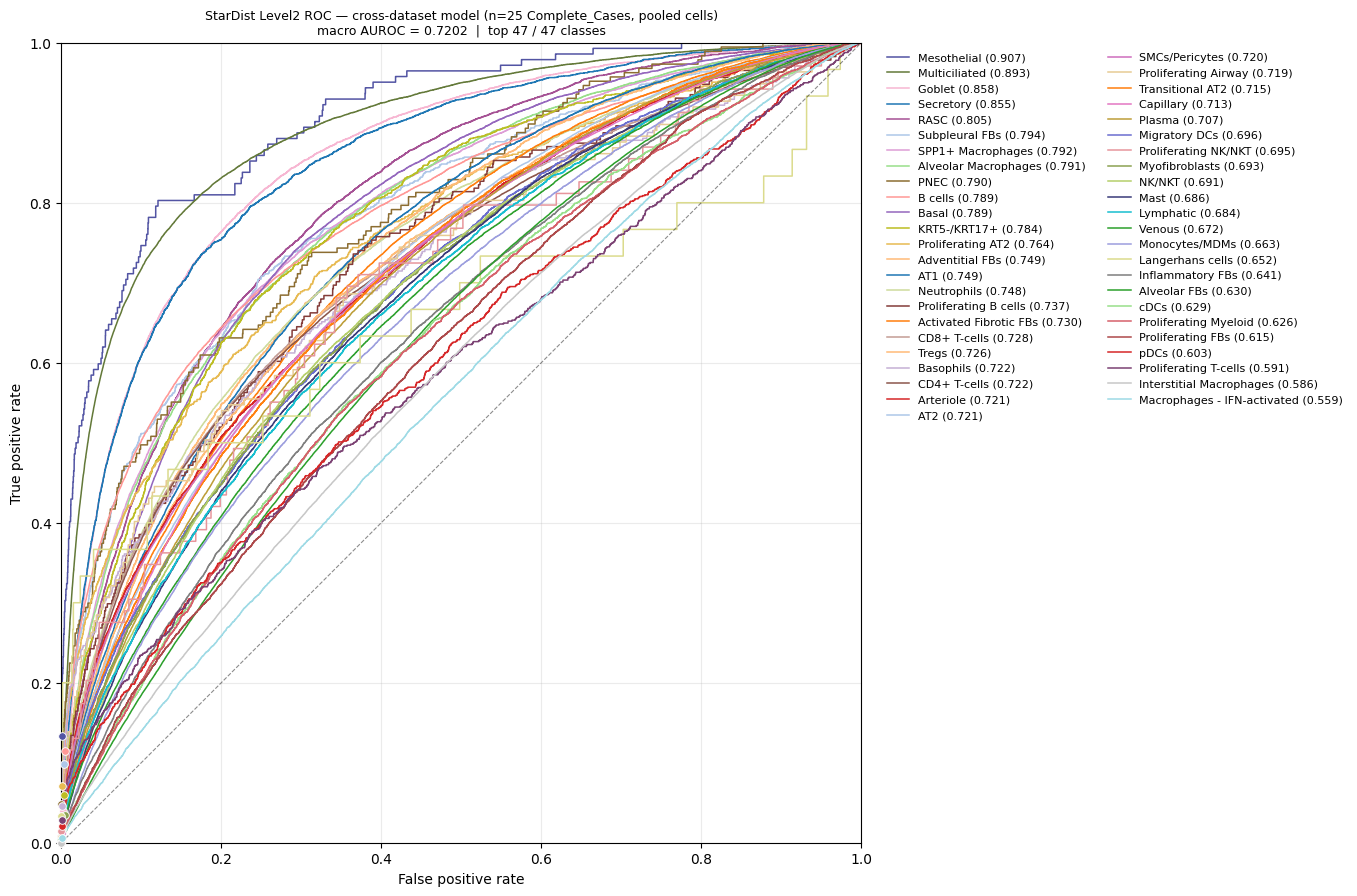

Pooled macro AUROC: 0.7202


,class_idx,class_name,auc_ovr,n_pos
21,21,Mesothelial,0.907232,142
24,24,Multiciliated,0.893035,26383
13,13,Goblet,0.858311,6269
40,40,Secretory,0.855089,3304
37,37,RASC,0.804628,5554
41,41,Subpleural FBs,0.794185,1042
39,39,SPP1+ Macrophages,0.791996,11496
5,5,Alveolar Macrophages,0.790735,9125
28,28,PNEC,0.790120,187
7,7,B cells,0.789185,16605


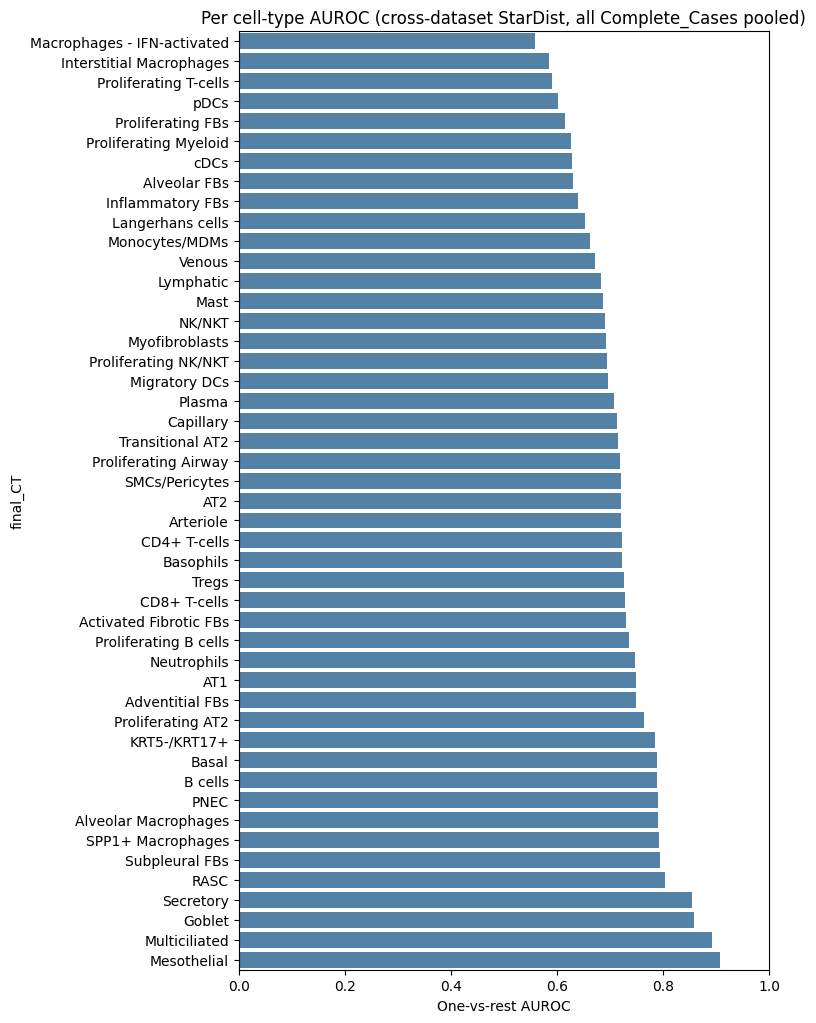

In [2]:
import sys
from pathlib import Path

_repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import importlib
import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    concat_stardist_auroc_level2_all_samples,
    plot_stardist_level2_roc_pooled,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-dataset model: StarDist predictions under Data/result/stardist/{sample}/
if "Xenium_lung_dir" not in globals():
    _path = "/home/lingyu/ssd2/Python/"
    Xenium_lung_dir = f"{_path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/"

DATA_ROOT = Path(Xenium_lung_dir) / "Data"
STARDIST_RESULT_ROOT = DATA_ROOT / "result" / "stardist"
OUT_DIR = DATA_ROOT / "result"

print(f"Discovering AUROC CSVs under {STARDIST_RESULT_ROOT} ...")
pooled = concat_stardist_auroc_level2_all_samples(
    STARDIST_RESULT_ROOT,
    out_dir=OUT_DIR,
    layout="pooled_stardist",
)
print(
    f"\nPooled: {len(pooled['concat_df']):,} cells from "
    f"{len(pooled['sample_paths'])} samples; "
    f"{len(pooled['global_class_names'])} global final_CT classes"
)
if pooled["missing_samples"]:
    print("Missing AUROC CSV:", pooled["missing_samples"])

roc_info_pooled = plot_stardist_level2_roc_pooled(
    pooled["y_true"],
    pooled["y_score"],
    pooled["global_class_names"],
    save_path=str(OUT_DIR / "roc_stardist_level2_cross_dataset_all_Complete_Cases_pooled.pdf"),
    title=(
        "StarDist Level2 ROC — cross-dataset model "
        f"(n={len(pooled['sample_paths'])} Complete_Cases, pooled cells)"
    ),
    pan_organ=PAN_ORGAN,
    figsize=(8.0, 8.0),
    max_curves=len(pooled["global_class_names"]),
)
plt.show()
if roc_info_pooled:
    print(f"Pooled macro AUROC: {roc_info_pooled['macro_auc']:.4f}")
    per_class = roc_info_pooled["per_class_auc"].sort_values("auc_ovr", ascending=False)
    display(per_class.head(15))
    per_class.to_csv(
        OUT_DIR / "roc_stardist_level2_cross_dataset_all_Complete_Cases_per_class_auc.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(8, max(5, 0.22 * len(per_class))))
    plot_df = per_class.sort_values("auc_ovr", ascending=True)
    sns.barplot(data=plot_df, y="class_name", x="auc_ovr", ax=ax, color="steelblue")
    ax.set_xlim(0, 1)
    ax.set_xlabel("One-vs-rest AUROC")
    ax.set_ylabel("final_CT")
    ax.set_title("Per cell-type AUROC (cross-dataset StarDist, all Complete_Cases pooled)")
    plt.tight_layout()
    plt.show()


### result2 - AUROC

Discovering AUROC CSVs under /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/result_auc/stardist ...
  THD0008: 36,781 cells, 47 local classes
  THD0011: 23,573 cells, 47 local classes
  TILD117LA: 10,288 cells, 47 local classes
  TILD117MA1: 9,345 cells, 47 local classes
  TILD175MA: 15,863 cells, 47 local classes
  VUHD069: 15,330 cells, 47 local classes
  VUHD095: 7,401 cells, 47 local classes
  VUHD113: 7,098 cells, 47 local classes
  VUHD116A: 2,920 cells, 47 local classes
  VUHD116B: 8,125 cells, 47 local classes
  VUILD102LA: 24,925 cells, 47 local classes
  VUILD102MA: 30,066 cells, 47 local classes
  VUILD104MA1: 20,754 cells, 47 local classes
  VUILD105MA2: 7,614 cells, 47 local classes
  VUILD106MA: 91,766 cells, 47 local classes
  VUILD107MA: 30,615 cells, 47 local classes
  VUILD110LA: 96,369 cells, 47 local classes
  VUILD115MA: 58,841 cells, 47 local classes
  VUILD48LA2: 3,558 cells, 47 local classes
  VUILD78

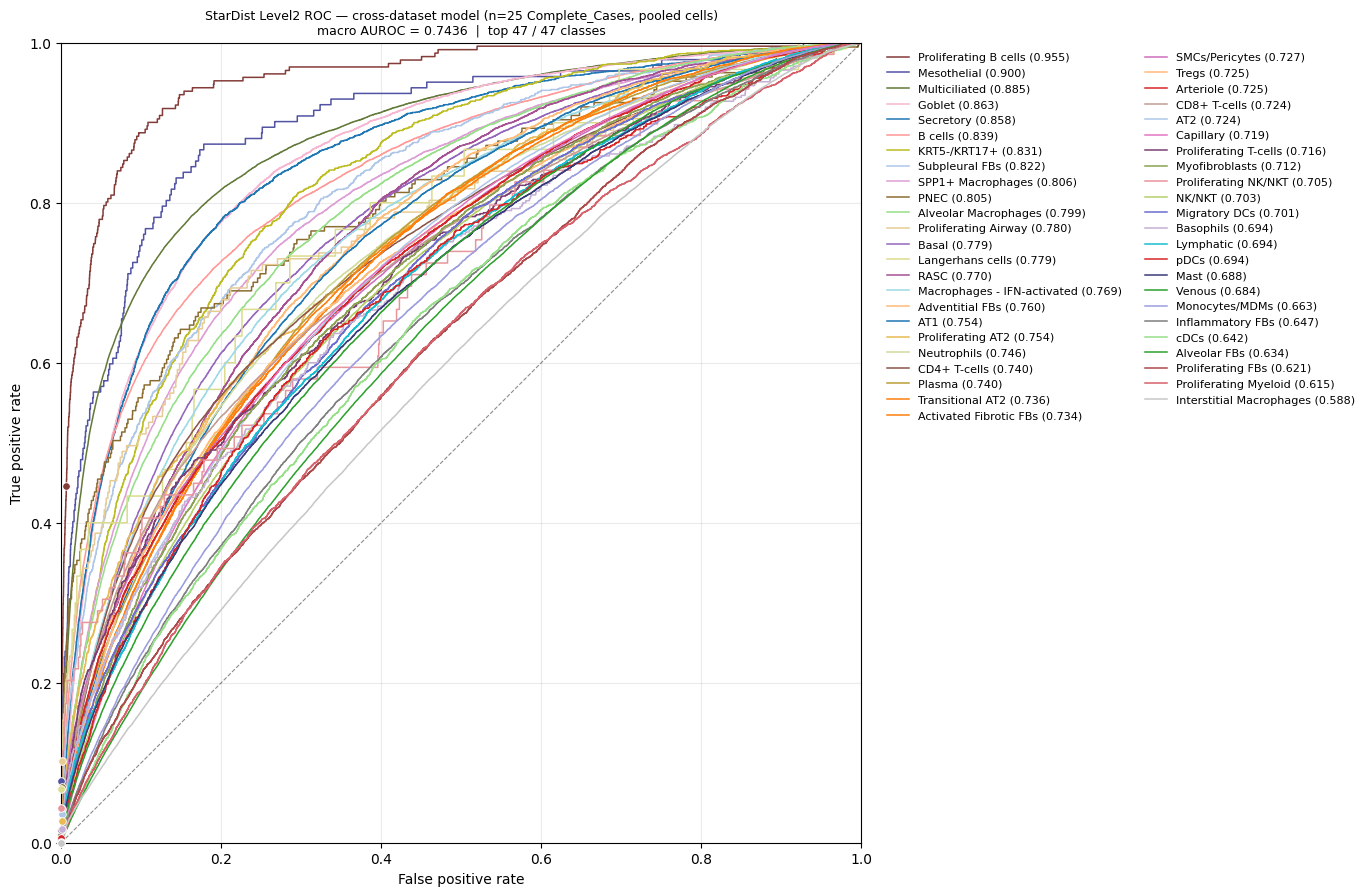

Pooled macro AUROC: 0.7436


,class_idx,class_name,auc_ovr,n_pos
32,32,Proliferating B cells,0.954510,231
21,21,Mesothelial,0.900226,142
24,24,Multiciliated,0.884744,26383
13,13,Goblet,0.862570,6269
40,40,Secretory,0.858024,3304
7,7,B cells,0.838726,16605
16,16,KRT5-/KRT17+,0.831144,1313
41,41,Subpleural FBs,0.822134,1042
39,39,SPP1+ Macrophages,0.805796,11496
28,28,PNEC,0.805211,187


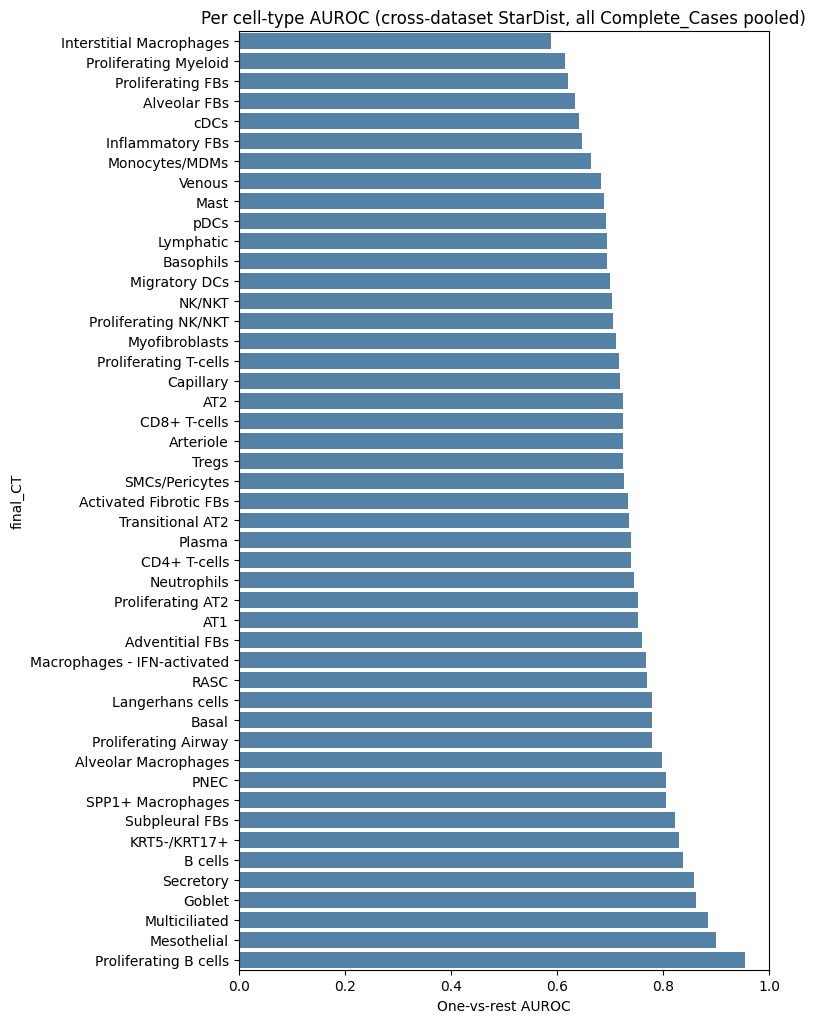

In [4]:
import sys
from pathlib import Path

_repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import importlib
import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    concat_stardist_auroc_level2_all_samples,
    plot_stardist_level2_roc_pooled,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-dataset model: StarDist predictions under Data/result/stardist/{sample}/
if "Xenium_lung_dir" not in globals():
    _path = "/home/lingyu/ssd2/Python/"
    Xenium_lung_dir = f"{_path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/"

DATA_ROOT = Path(Xenium_lung_dir) / "Data"
STARDIST_RESULT_ROOT = DATA_ROOT / "result_auc" / "stardist"
OUT_DIR = DATA_ROOT / "result_auc"

print(f"Discovering AUROC CSVs under {STARDIST_RESULT_ROOT} ...")
pooled = concat_stardist_auroc_level2_all_samples(
    STARDIST_RESULT_ROOT,
    out_dir=OUT_DIR,
    layout="pooled_stardist",
)
print(
    f"\nPooled: {len(pooled['concat_df']):,} cells from "
    f"{len(pooled['sample_paths'])} samples; "
    f"{len(pooled['global_class_names'])} global final_CT classes"
)
if pooled["missing_samples"]:
    print("Missing AUROC CSV:", pooled["missing_samples"])

roc_info_pooled = plot_stardist_level2_roc_pooled(
    pooled["y_true"],
    pooled["y_score"],
    pooled["global_class_names"],
    save_path=str(OUT_DIR / "roc_stardist_level2_cross_dataset_all_Complete_Cases_pooled.pdf"),
    title=(
        "StarDist Level2 ROC — cross-dataset model "
        f"(n={len(pooled['sample_paths'])} Complete_Cases, pooled cells)"
    ),
    pan_organ=PAN_ORGAN,
    figsize=(8.0, 8.0),
    max_curves=len(pooled["global_class_names"]),
)
plt.show()
if roc_info_pooled:
    print(f"Pooled macro AUROC: {roc_info_pooled['macro_auc']:.4f}")
    per_class = roc_info_pooled["per_class_auc"].sort_values("auc_ovr", ascending=False)
    display(per_class.head(15))
    per_class.to_csv(
        OUT_DIR / "roc_stardist_level2_cross_dataset_all_Complete_Cases_per_class_auc.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(8, max(5, 0.22 * len(per_class))))
    plot_df = per_class.sort_values("auc_ovr", ascending=True)
    sns.barplot(data=plot_df, y="class_name", x="auc_ovr", ax=ax, color="steelblue")
    ax.set_xlim(0, 1)
    ax.set_xlabel("One-vs-rest AUROC")
    ax.set_ylabel("final_CT")
    ax.set_title("Per cell-type AUROC (cross-dataset StarDist, all Complete_Cases pooled)")
    plt.tight_layout()
    plt.show()


### result_all_spatial AUROC
Pooled macro AUROC: 0.8097

##### AUROC


=== L2 | discovering validation_external_stardist_matched_AUROC.csv ===


  THD0008: 36,781 cells, 47 local classes
  THD0011: 23,573 cells, 47 local classes
  TILD117LA: 10,288 cells, 47 local classes
  TILD117MA1: 9,345 cells, 47 local classes
  TILD175MA: 15,863 cells, 47 local classes
  VUHD069: 15,330 cells, 47 local classes
  VUHD095: 7,401 cells, 47 local classes
  VUHD113: 7,098 cells, 47 local classes
  VUHD116A: 2,920 cells, 47 local classes
  VUHD116B: 8,125 cells, 47 local classes
  VUILD102LA: 24,925 cells, 47 local classes
  VUILD102MA: 30,066 cells, 47 local classes
  VUILD104MA1: 20,754 cells, 47 local classes
  VUILD105MA2: 7,614 cells, 47 local classes
  VUILD106MA: 91,766 cells, 47 local classes
  VUILD107MA: 30,615 cells, 47 local classes
  VUILD110LA: 96,369 cells, 47 local classes
  VUILD115MA: 58,841 cells, 47 local classes
  VUILD48LA2: 3,558 cells, 47 local classes
  VUILD78LA: 13,125 cells, 47 local classes
  VUILD78MA: 29,169 cells, 47 local classes
  VUILD91LA: 13,458 cells, 47 local classes
  VUILD91MA: 9,977 cells, 47 local clas

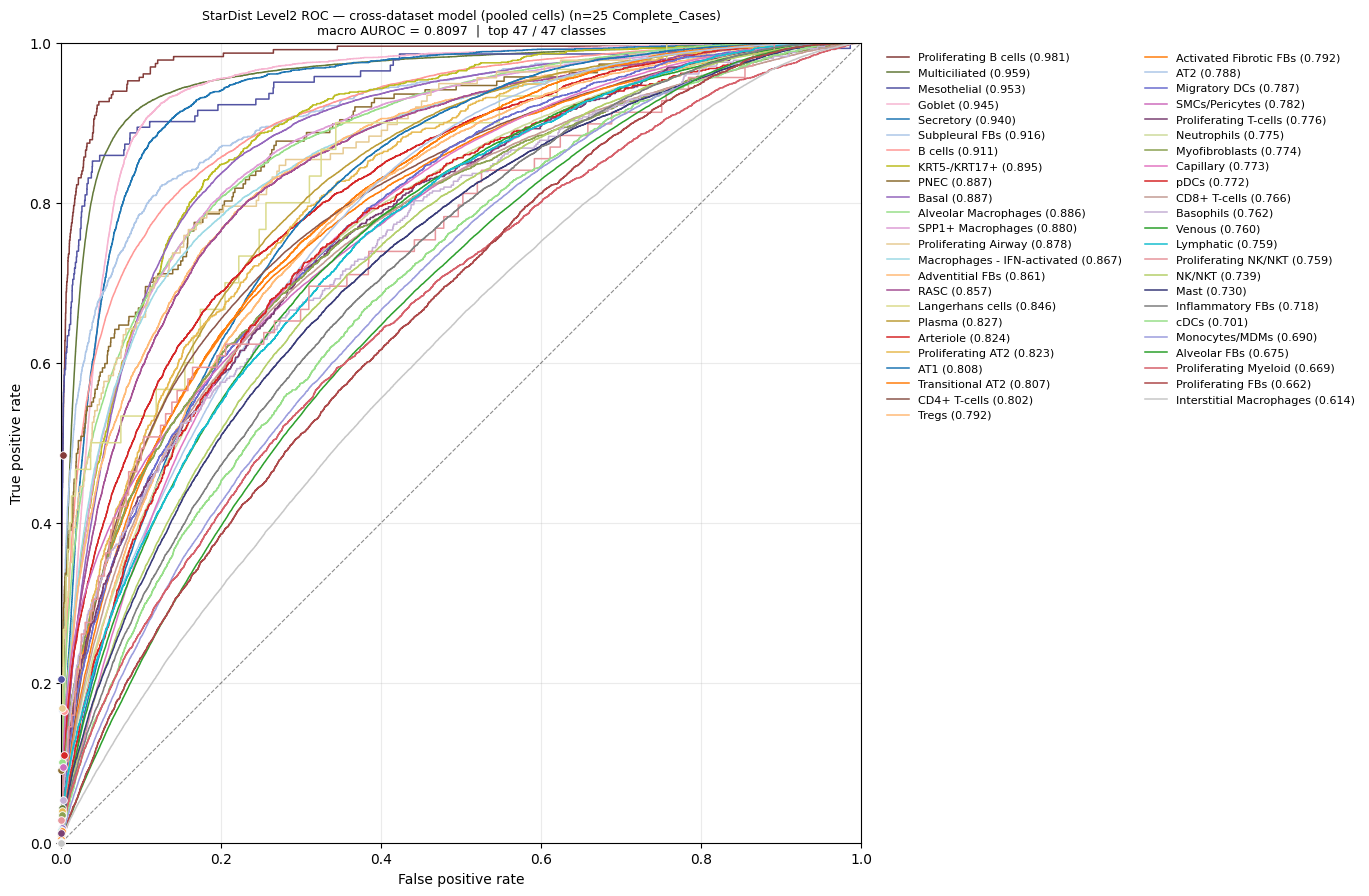

Pooled macro AUROC (L2): 0.8097


{'pooled': {'tier': 'l2',
  'concat_df':            sample     cell_id     ground_truth_final_CT  \
  0         THD0008  aaaaaaab-1                 Capillary   
  1         THD0008  aaaaaaad-1                    Venous   
  2         THD0008  aaaaaaae-1                    NK/NKT   
  3         THD0008  aaaaaabe-1                 Capillary   
  4         THD0008  aaaaaabh-1                    NK/NKT   
  ...           ...         ...                       ...   
  635257  VUILD96MA  aaaaoind-1  Interstitial Macrophages   
  635258  VUILD96MA  aaaaoine-1              CD8+ T-cells   
  635259  VUILD96MA  aaaaoing-1  Interstitial Macrophages   
  635260  VUILD96MA  aaaaoinh-1     Proliferating T-cells   
  635261  VUILD96MA  aaaaoini-1  Interstitial Macrophages   
  
         predict_stardist_final_CT  ground_truth_global_idx    prob_0    prob_1  \
  0                            AT2                       12  0.031090  0.055587   
  1                      Capillary                       44 

In [4]:
import sys
from pathlib import Path

_repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import importlib
import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
from uni_label_cv_helpers import plot_pooled_stardist_tier_roc

if "Xenium_lung_dir" not in globals():
    _path = "/home/lingyu/ssd2/Python/"
    Xenium_lung_dir = f"{_path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/"

DATA_ROOT = Path(Xenium_lung_dir) / "Data"
STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial" / "stardist"
OUT_DIR = DATA_ROOT / "result_all_spatial"

plot_pooled_stardist_tier_roc(STARDIST_RESULT_ROOT, OUT_DIR, "l2")



=== L1 | discovering validation_external_stardist_matched_AUROC_level1.csv ===
  THD0008: 36,781 cells, 4 local classes
  THD0011: 23,573 cells, 4 local classes
  TILD117LA: 10,288 cells, 4 local classes
  TILD117MA1: 9,345 cells, 4 local classes
  TILD175MA: 15,863 cells, 4 local classes
  VUHD069: 15,330 cells, 4 local classes
  VUHD095: 7,401 cells, 4 local classes
  VUHD113: 7,098 cells, 4 local classes
  VUHD116A: 2,920 cells, 4 local classes
  VUHD116B: 8,125 cells, 4 local classes
  VUILD102LA: 24,925 cells, 4 local classes
  VUILD102MA: 30,066 cells, 4 local classes
  VUILD104MA1: 20,754 cells, 4 local classes
  VUILD105MA2: 7,614 cells, 4 local classes
  VUILD106MA: 91,766 cells, 4 local classes
  VUILD107MA: 30,615 cells, 4 local classes
  VUILD110LA: 96,369 cells, 4 local classes
  VUILD115MA: 58,841 cells, 4 local classes
  VUILD48LA2: 3,558 cells, 4 local classes
  VUILD78LA: 13,125 cells, 4 local classes
  VUILD78MA: 29,169 cells, 4 local classes
  VUILD91LA: 13,458 cell

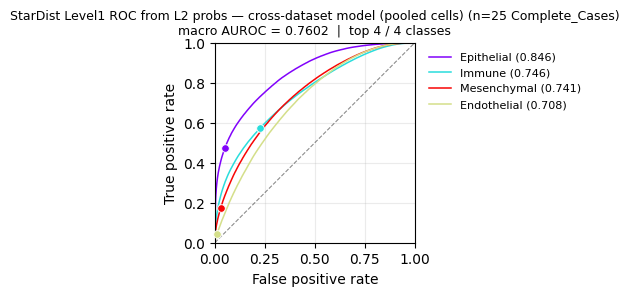

Pooled macro AUROC (L1): 0.7602

=== L12 | discovering validation_external_stardist_matched_AUROC_level12.csv ===
  THD0008: 36,781 cells, 6 local classes
  THD0011: 23,573 cells, 6 local classes
  TILD117LA: 10,288 cells, 6 local classes
  TILD117MA1: 9,345 cells, 6 local classes
  TILD175MA: 15,863 cells, 6 local classes
  VUHD069: 15,330 cells, 6 local classes
  VUHD095: 7,401 cells, 6 local classes
  VUHD113: 7,098 cells, 6 local classes
  VUHD116A: 2,920 cells, 6 local classes
  VUHD116B: 8,125 cells, 6 local classes
  VUILD102LA: 24,925 cells, 6 local classes
  VUILD102MA: 30,066 cells, 6 local classes
  VUILD104MA1: 20,754 cells, 6 local classes
  VUILD105MA2: 7,614 cells, 6 local classes
  VUILD106MA: 91,766 cells, 6 local classes
  VUILD107MA: 30,615 cells, 6 local classes
  VUILD110LA: 96,369 cells, 6 local classes
  VUILD115MA: 58,841 cells, 6 local classes
  VUILD48LA2: 3,558 cells, 6 local classes
  VUILD78LA: 13,125 cells, 6 local classes
  VUILD78MA: 29,169 cells, 6 loca

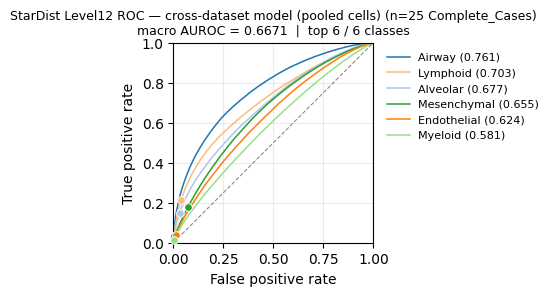

Pooled macro AUROC (L12): 0.6671

=== L3 | discovering validation_external_stardist_matched_AUROC_level3.csv ===
  THD0008: 36,781 cells, 12 local classes
  THD0011: 23,573 cells, 12 local classes
  TILD117LA: 10,288 cells, 12 local classes
  TILD117MA1: 9,345 cells, 12 local classes
  TILD175MA: 15,863 cells, 12 local classes
  VUHD069: 15,330 cells, 12 local classes
  VUHD095: 7,401 cells, 12 local classes
  VUHD113: 7,098 cells, 12 local classes
  VUHD116A: 2,920 cells, 12 local classes
  VUHD116B: 8,125 cells, 12 local classes
  VUILD102LA: 24,925 cells, 12 local classes
  VUILD102MA: 30,066 cells, 12 local classes
  VUILD104MA1: 20,754 cells, 12 local classes
  VUILD105MA2: 7,614 cells, 12 local classes
  VUILD106MA: 91,766 cells, 12 local classes
  VUILD107MA: 30,615 cells, 12 local classes
  VUILD110LA: 96,369 cells, 12 local classes
  VUILD115MA: 58,841 cells, 12 local classes
  VUILD48LA2: 3,558 cells, 12 local classes
  VUILD78LA: 13,125 cells, 12 local classes
  VUILD78MA: 2

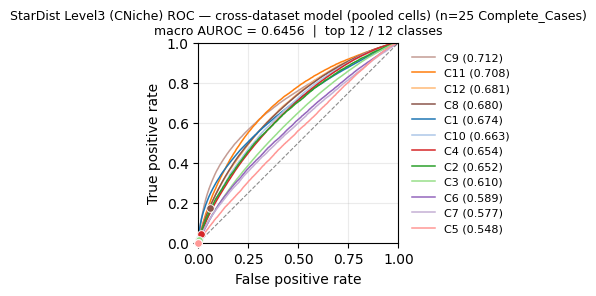

Pooled macro AUROC (L3): 0.6456

=== L4 | discovering validation_external_stardist_matched_AUROC_level4.csv ===
  THD0008: 36,781 cells, 12 local classes
  THD0011: 23,573 cells, 12 local classes
  TILD117LA: 10,288 cells, 12 local classes
  TILD117MA1: 9,345 cells, 12 local classes
  TILD175MA: 15,863 cells, 12 local classes
  VUHD069: 15,330 cells, 12 local classes
  VUHD095: 7,401 cells, 12 local classes
  VUHD113: 7,098 cells, 12 local classes
  VUHD116A: 2,920 cells, 12 local classes
  VUHD116B: 8,125 cells, 12 local classes
  VUILD102LA: 24,925 cells, 12 local classes
  VUILD102MA: 30,066 cells, 12 local classes
  VUILD104MA1: 20,754 cells, 12 local classes
  VUILD105MA2: 7,614 cells, 12 local classes
  VUILD106MA: 91,766 cells, 12 local classes
  VUILD107MA: 30,615 cells, 12 local classes
  VUILD110LA: 96,369 cells, 12 local classes
  VUILD115MA: 58,841 cells, 12 local classes
  VUILD48LA2: 3,558 cells, 12 local classes
  VUILD78LA: 13,125 cells, 12 local classes
  VUILD78MA: 29

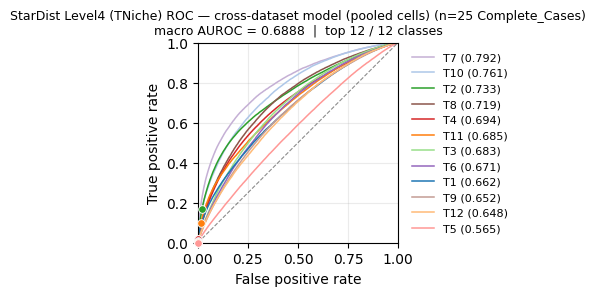

Pooled macro AUROC (L4): 0.6888


In [7]:
# Pooled cross-dataset ROC for L1 / L12 / L3 / L4 (ROC curve only)
from uni_label_cv_helpers import plot_pooled_stardist_tier_roc

for _tier in ("l1", "l12", "l3", "l4"):
    try:
        plot_pooled_stardist_tier_roc(STARDIST_RESULT_ROOT, OUT_DIR, _tier, figsize=(2.0, 2.0))
    except FileNotFoundError as exc:
        print(f"Skip {_tier.upper()}: {exc}")

##### StarDist macro AUROC vs clinical groups

Per-sample macro AUROC (from saved AUROC CSVs at each tier) compared across **Status** and **Sample_Affect_Pairing** — same boxplot style and Mann–Whitney / Kruskal–Wallis tests as the lung `histology_derived_niche_index` notebook.

This cell only uses `hdni.load_clinical_info` for Xenium clinical columns. It does **not** use the shared CODEX TLS / SRI / TNI engine in `Hist2Pheno_pkg/histology_niche_index.py`.

Run the ROC setup cell above first (`STARDIST_RESULT_ROOT`, `OUT_DIR`).


In [12]:
OUT_DIR

PosixPath('/home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/result_all_spatial')


=== L2 macro AUROC vs clinical groups ===


,clinical_variable,metric_col,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Status,macro_auc_l2,Mann-Whitney U,0.002347,15.000000,2,"[Control, Disease]","[0.6744191488309885, 0.7549407369297709]","[0.6744191488309885, 0.7549407369297709]",2.629565
1,Sample_Affect_Pairing,macro_auc_l2,Kruskal-Wallis,0.004852,10.656863,3,"[Unaffected, Less_Affected, More_Affected]","[0.6744191488309885, 0.7468242307292483, 0.784...","[0.6744191488309885, 0.7468242307292483, 0.784...",2.314108


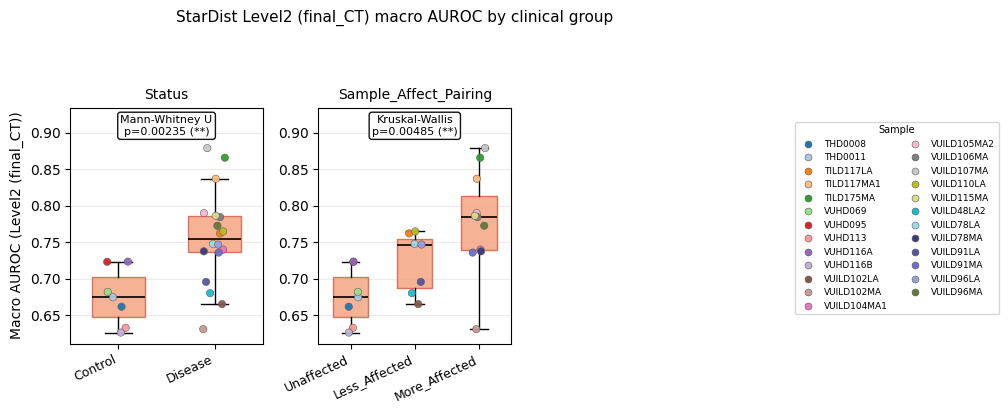


=== L1 macro AUROC vs clinical groups ===


,clinical_variable,metric_col,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Status,macro_auc_l1,Mann-Whitney U,0.000549,10.000000,2,"[Control, Disease]","[0.6248235988268696, 0.7529308384524918]","[0.6248235988268696, 0.7529308384524918]",3.260270
1,Sample_Affect_Pairing,macro_auc_l1,Kruskal-Wallis,0.001265,13.345534,3,"[Unaffected, Less_Affected, More_Affected]","[0.6248235988268696, 0.7182342230116174, 0.768...","[0.6248235988268696, 0.7182342230116174, 0.768...",2.897946


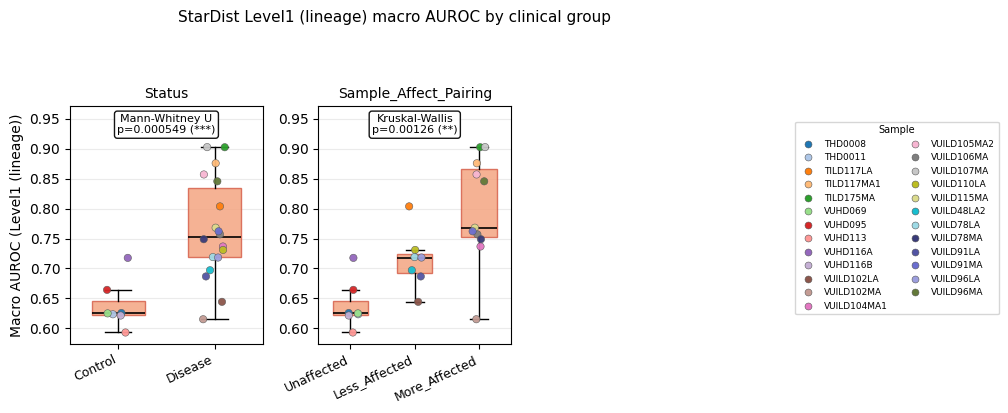


=== L12 macro AUROC vs clinical groups ===


,clinical_variable,metric_col,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Status,macro_auc_l12,Mann-Whitney U,0.007647,20.000000,2,"[Control, Disease]","[0.6211090658356874, 0.6895036504341195]","[0.6211090658356874, 0.6895036504341195]",2.116499
1,Sample_Affect_Pairing,macro_auc_l12,Kruskal-Wallis,0.010044,9.201518,3,"[Unaffected, Less_Affected, More_Affected]","[0.6211090658356874, 0.6583750036345196, 0.701...","[0.6211090658356874, 0.6583750036345196, 0.701...",1.998084


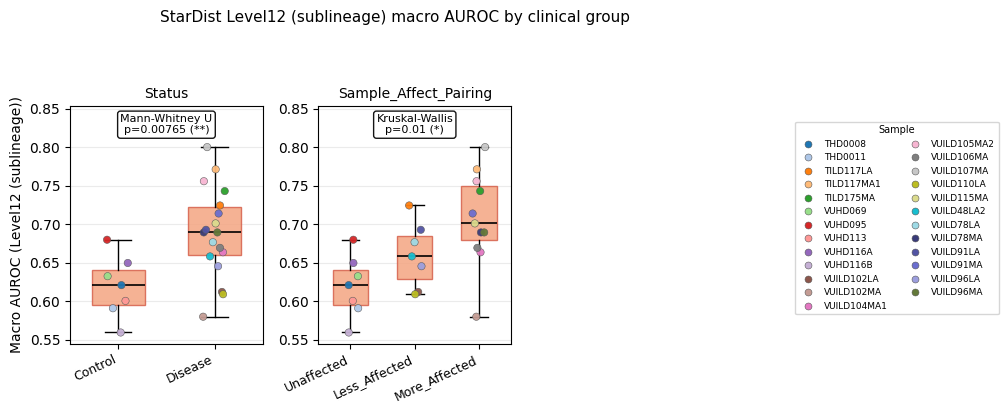


=== L3 macro AUROC vs clinical groups ===


,clinical_variable,metric_col,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Status,macro_auc_l3,Mann-Whitney U,0.198144,41.000000,2,"[Control, Disease]","[0.5776186899383989, 0.6178351702770473]","[0.5776186899383989, 0.6178351702770473]",0.703018
1,Sample_Affect_Pairing,macro_auc_l3,Kruskal-Wallis,0.041858,6.346933,3,"[Unaffected, Less_Affected, More_Affected]","[0.5776186899383989, 0.5955402559831581, 0.636...","[0.5776186899383989, 0.5955402559831581, 0.636...",1.378219


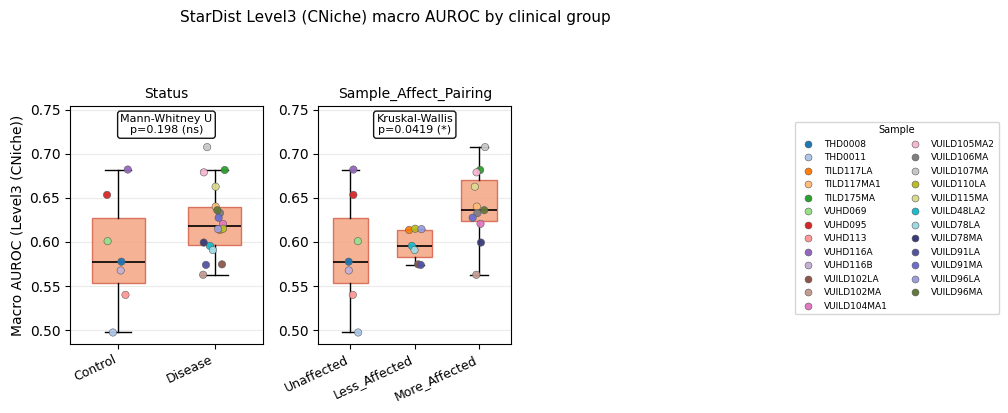


=== L4 macro AUROC vs clinical groups ===


,clinical_variable,metric_col,test,p_value,statistic,n_groups,group_labels,group_median_q4,group_median_values,neg_log10_p
0,Status,macro_auc_l4,Mann-Whitney U,0.002347,15.000000,2,"[Control, Disease]","[0.6342257097933278, 0.6918305430411871]","[0.6342257097933278, 0.6918305430411871]",2.629565
1,Sample_Affect_Pairing,macro_auc_l4,Kruskal-Wallis,0.007497,9.786533,3,"[Unaffected, Less_Affected, More_Affected]","[0.6342257097933278, 0.689183831922186, 0.7073...","[0.6342257097933278, 0.689183831922186, 0.7073...",2.125119


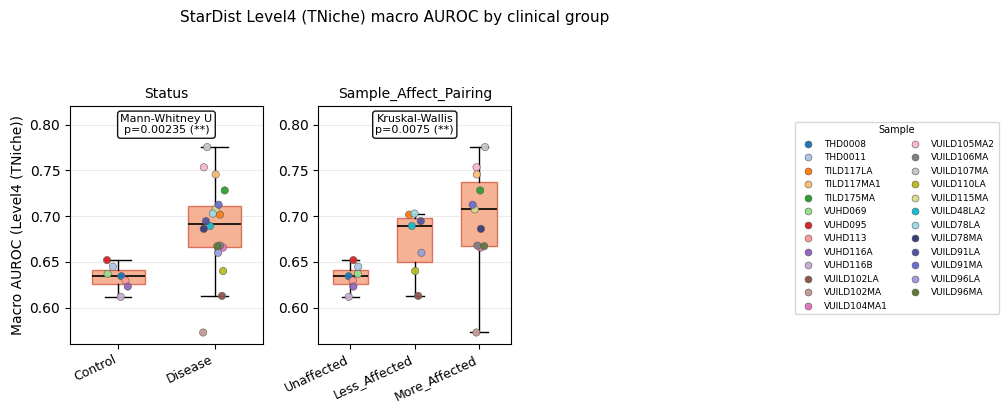

,Sample,macro_auc_l2,macro_auc_l1,macro_auc_l12,macro_auc_l3,macro_auc_l4
0,THD0008,0.661482,0.625427,0.621109,0.577619,0.634226
1,THD0011,0.674419,0.623322,0.591109,0.497211,0.644669
2,TILD117LA,0.762145,0.803813,0.724477,0.613668,0.701548
3,TILD117MA1,0.837162,0.875921,0.771390,0.640199,0.745526
4,TILD175MA,0.866059,0.902758,0.743152,0.681736,0.728029
5,VUHD069,0.681871,0.624824,0.632696,0.600943,0.636718
6,VUHD095,0.723157,0.664133,0.680005,0.653502,0.651818
7,VUHD113,0.632518,0.592832,0.600659,0.539941,0.629403
8,VUHD116A,0.723415,0.717638,0.649836,0.682281,0.622898
9,VUHD116B,0.626009,0.621241,0.559631,0.567650,0.611635


In [ ]:
import importlib
import histology_derived_niche_index as hdni
import uni_label_cv_helpers as uni_nb
importlib.reload(hdni)
importlib.reload(uni_nb)

# Lung clinical table only (not Hist2Pheno_pkg/histology_niche_index SRI/TNI).
from histology_derived_niche_index import load_clinical_info
from uni_label_cv_helpers import analyze_stardist_macro_auroc_by_clinical

clinical_info = load_clinical_info()
stardist_auroc_clinical = analyze_stardist_macro_auroc_by_clinical(
    STARDIST_RESULT_ROOT,
    clinical_info,
    layout="pooled_stardist",
    figsize=(8, 4),
    legend_ncol=2,
    # save_dir=OUT_DIR / "stardist_auroc_clinical",
)
display(stardist_auroc_clinical["auroc_df"])


### result_all_spatial_k8_bs8192

Pooled macro AUROC: 0.8078

Discovering AUROC CSVs under /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/result_all_spatial_k8_bs8192/stardist ...
  THD0008: 36,781 cells, 47 local classes
  THD0011: 23,573 cells, 47 local classes
  TILD117LA: 10,288 cells, 47 local classes
  TILD117MA1: 9,345 cells, 47 local classes
  TILD175MA: 15,863 cells, 47 local classes
  VUHD069: 15,330 cells, 47 local classes
  VUHD095: 7,401 cells, 47 local classes
  VUHD113: 7,098 cells, 47 local classes
  VUHD116A: 2,920 cells, 47 local classes
  VUHD116B: 8,125 cells, 47 local classes
  VUILD102LA: 24,925 cells, 47 local classes
  VUILD102MA: 30,066 cells, 47 local classes
  VUILD104MA1: 20,754 cells, 47 local classes
  VUILD105MA2: 7,614 cells, 47 local classes
  VUILD106MA: 91,766 cells, 47 local classes
  VUILD107MA: 30,615 cells, 47 local classes
  VUILD110LA: 96,369 cells, 47 local classes
  VUILD115MA: 58,841 cells, 47 local classes
  VUILD48LA2: 3,558 cells, 47 local

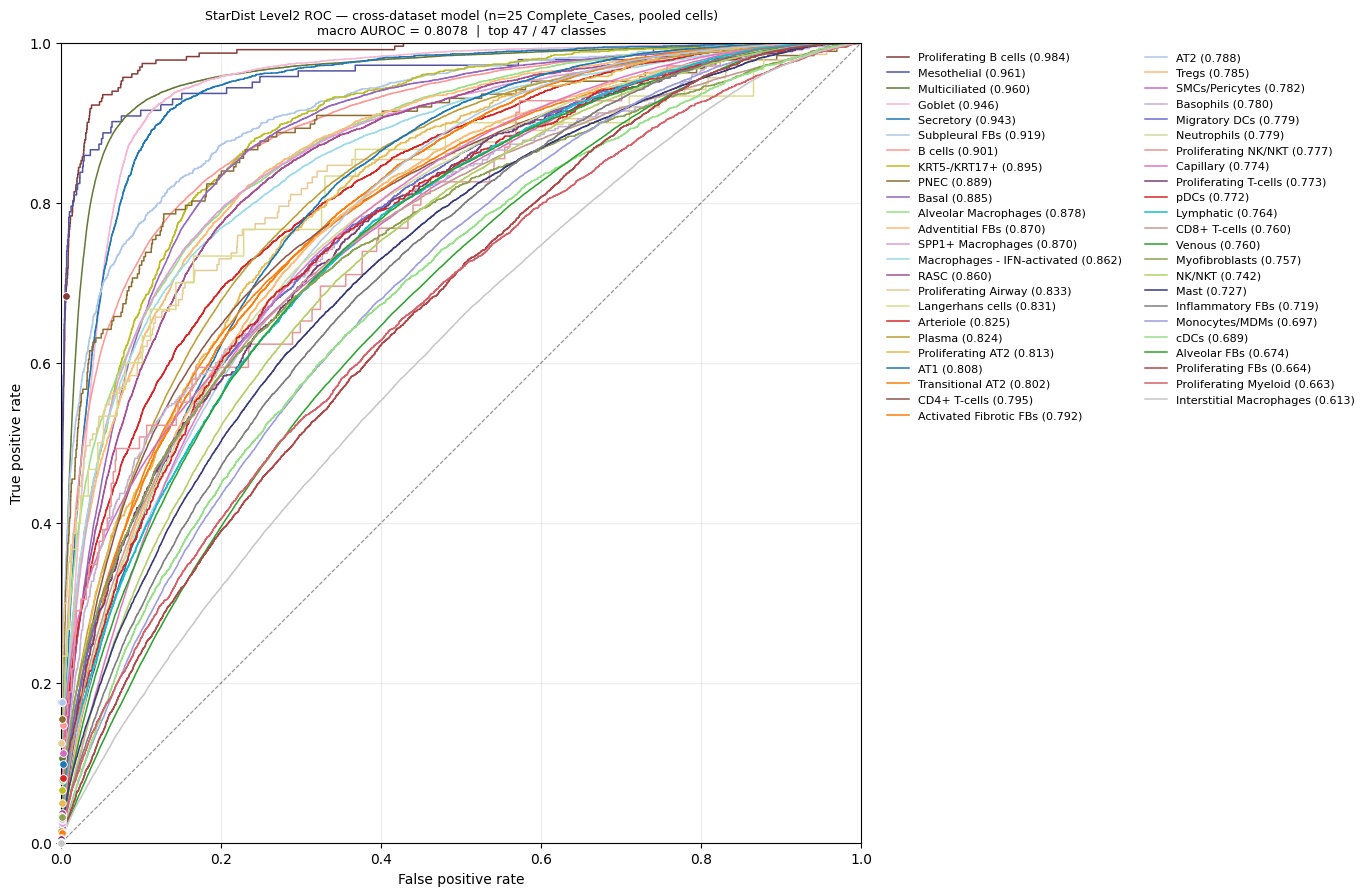

Pooled macro AUROC: 0.8078


,class_idx,class_name,auc_ovr,n_pos
32,32,Proliferating B cells,0.984408,231
21,21,Mesothelial,0.960531,142
24,24,Multiciliated,0.959940,26383
13,13,Goblet,0.946258,6269
40,40,Secretory,0.943084,3304
41,41,Subpleural FBs,0.918586,1042
7,7,B cells,0.901499,16605
16,16,KRT5-/KRT17+,0.894626,1313
28,28,PNEC,0.888935,187
8,8,Basal,0.884758,14111


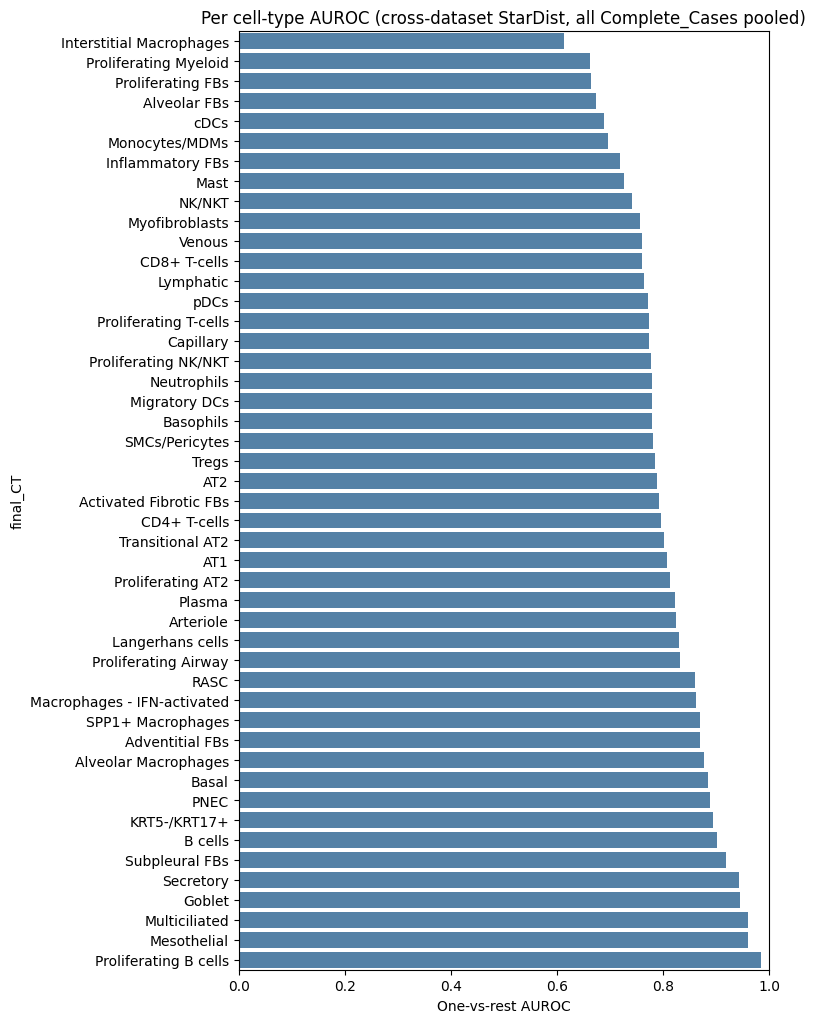

In [ ]:
# import sys
# from pathlib import Path

# _repo = Path("/home/lingyu/ssd2/Python/Hist2Pheno/code")
# for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung"):
#     if str(_p) not in sys.path:
#         sys.path.insert(0, str(_p))

# import importlib
# import uni_label_cv_helpers as uni_nb
# importlib.reload(uni_nb)
# from uni_label_cv_helpers import (
#     concat_stardist_auroc_level2_all_samples,
#     plot_stardist_level2_roc_pooled,
# )
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Cross-dataset model: StarDist predictions under Data/result/stardist/{sample}/
# if "Xenium_lung_dir" not in globals():
#     _path = "/home/lingyu/ssd2/Python/"
#     Xenium_lung_dir = f"{_path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/"

# DATA_ROOT = Path(Xenium_lung_dir) / "Data"
# STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial_k8_bs8192" / "stardist"
# OUT_DIR = DATA_ROOT / "result_all_spatial_k8_bs8192"

# print(f"Discovering AUROC CSVs under {STARDIST_RESULT_ROOT} ...")
# pooled = concat_stardist_auroc_level2_all_samples(
#     STARDIST_RESULT_ROOT,
#     out_dir=OUT_DIR,
#     layout="pooled_stardist",
# )
# print(
#     f"\nPooled: {len(pooled['concat_df']):,} cells from "
#     f"{len(pooled['sample_paths'])} samples; "
#     f"{len(pooled['global_class_names'])} global final_CT classes"
# )
# if pooled["missing_samples"]:
#     print("Missing AUROC CSV:", pooled["missing_samples"])

# roc_info_pooled = plot_stardist_level2_roc_pooled(
#     pooled["y_true"],
#     pooled["y_score"],
#     pooled["global_class_names"],
#     save_path=str(OUT_DIR / "roc_stardist_level2_cross_dataset_all_Complete_Cases_pooled.pdf"),
#     title=(
#         "StarDist Level2 ROC — cross-dataset model "
#         f"(n={len(pooled['sample_paths'])} Complete_Cases, pooled cells)"
#     ),
#     pan_organ=PAN_ORGAN,
#     figsize=(8.0, 8.0),
#     max_curves=len(pooled["global_class_names"]),
# )
# plt.show()
# if roc_info_pooled:
#     print(f"Pooled macro AUROC: {roc_info_pooled['macro_auc']:.4f}")
#     per_class = roc_info_pooled["per_class_auc"].sort_values("auc_ovr", ascending=False)
#     display(per_class.head(15))
#     per_class.to_csv(
#         OUT_DIR / "roc_stardist_level2_cross_dataset_all_Complete_Cases_per_class_auc.csv",
#         index=False,
#     )

#     fig, ax = plt.subplots(figsize=(8, max(5, 0.22 * len(per_class))))
#     plot_df = per_class.sort_values("auc_ovr", ascending=True)
#     sns.barplot(data=plot_df, y="class_name", x="auc_ovr", ax=ax, color="steelblue")
#     ax.set_xlim(0, 1)
#     ax.set_xlabel("One-vs-rest AUROC")
#     ax.set_ylabel("final_CT")
#     ax.set_title("Per cell-type AUROC (cross-dataset StarDist, all Complete_Cases pooled)")
#     plt.tight_layout()
#     plt.show()
